In [1]:
# Loading dataset

import pandas as pd

drug_df = pd.read_csv("Data/drug.csv")
drug_df.head(3)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC


In [3]:
# Train Test split

from sklearn.model_selection import train_test_split

X = drug_df.drop("Drug", axis=1).values
y = drug_df.Drug.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=91)

In [4]:
# Creating the pipelines

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

cat_col = [1, 2, 3]
num_col = [0, 4]

transform = ColumnTransformer(
    [
        ("encoder", OrdinalEncoder(), cat_col),
        ("num_imputer", SimpleImputer(strategy="median"), num_col),
        ("num_scaler", StandardScaler(), num_col)
    ]
)

pipe = Pipeline(
    steps=[
        ("prerpocessing", transform),
        ("model", RandomForestClassifier(n_estimators=20, random_state=12))
    ]
)

pipe.fit(X_train, y_train)

,steps,"[('prerpocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encoder', ...), ('num_imputer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [5]:
# Model Evaluation

from sklearn.metrics import accuracy_score, f1_score


predictions = pipe.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average= "macro")

print(f"Accuracy:, {accuracy*100}%, F1 score: {f1}")

# Save to metrics file
with open("Results/metrics.txt", "w") as outfile:
    outfile.write(f"\nAccuracy = {accuracy}, F1 score: {f1}")

Accuracy:, 96.66666666666667%, F1 score: 0.946967418546366


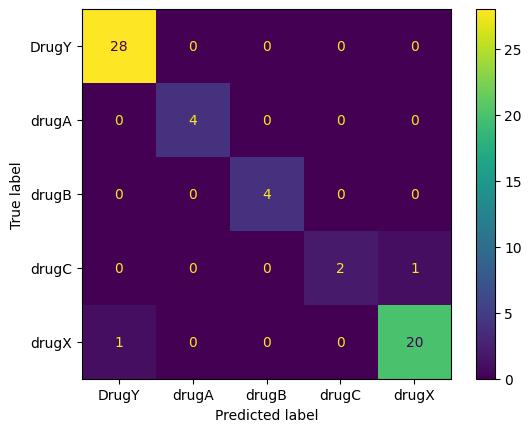

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, predictions, labels=pipe.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
disp.plot()
plt.savefig("Results/model_results.png", dpi=120)

In [7]:
# Saving the model
import skops.io as sio

sio.dump(pipe, "Model/drug_pipeline.skops")